# 0. Generamos los Dfs 

## Nacionales

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns


In [5]:
def generar_df(carpeta):
    dfs = {}

    for archivo in os.listdir(carpeta):
        if archivo.endswith(".csv"):
            ruta = os.path.join(carpeta, archivo)
            print(f"Procesando: {archivo}")

            nombre = os.path.splitext(archivo)[0]  # sin .csv
            dfs[nombre] = pd.read_csv(ruta)

    return dfs


In [6]:
dfs = generar_df(r"C:\Users\damia\OneDrive\Desktop\Simulacion_Empresarial\23 March\23 March")

# Ver todos los nombres generados
dfs.keys()

Procesando: 01_Demografia_cleaning_16.csv
Procesando: 01_Demografia_cleaning_21.csv
Procesando: 02_Product_Activos_cleaning_16.csv
Procesando: 02_Product_Activos_cleaning_21.csv
Procesando: 04_Conocimientos_Financieros_2016_GEN_Cleaned.csv
Procesando: 04_Conocimientos_Financieros_2021_GEN_Cleaned.csv
Procesando: 09_Gestion_Gastos_y_Deudas_2016_GEN_Cleaned.csv
Procesando: 09_Gestion_Gastos_y_Deudas_2021_GEN_Cleaned.csv
Procesando: comparacion_competencias.csv
Procesando: heatmap_competencia_laboral.csv
Procesando: impagos_nivel_competencia.csv


dict_keys(['01_Demografia_cleaning_16', '01_Demografia_cleaning_21', '02_Product_Activos_cleaning_16', '02_Product_Activos_cleaning_21', '04_Conocimientos_Financieros_2016_GEN_Cleaned', '04_Conocimientos_Financieros_2021_GEN_Cleaned', '09_Gestion_Gastos_y_Deudas_2016_GEN_Cleaned', '09_Gestion_Gastos_y_Deudas_2021_GEN_Cleaned', 'comparacion_competencias', 'heatmap_competencia_laboral', 'impagos_nivel_competencia'])

In [7]:
df_demografia16 = dfs["01_Demografia_cleaning_16"]
df_demografia21 = dfs["01_Demografia_cleaning_21"]

df_product16 = dfs["02_Product_Activos_cleaning_16"]
df_product21 = dfs["02_Product_Activos_cleaning_21"]

df_conocimientos16 = dfs["04_Conocimientos_Financieros_2016_GEN_Cleaned"]
df_conocimientos21 = dfs["04_Conocimientos_Financieros_2021_GEN_Cleaned"]

df_gestiones16 = dfs["09_Gestion_Gastos_y_Deudas_2016_GEN_Cleaned"]
df_gestiones21 = dfs["09_Gestion_Gastos_y_Deudas_2021_GEN_Cleaned"]

In [10]:
# Asegurar que todos los índices están alineados
df_demografia16 = df_demografia16.reset_index(drop=True)
df_gestiones16 = df_gestiones16.reset_index(drop=True)

df_demografia21 = df_demografia21.reset_index(drop=True)
df_gestiones21 = df_gestiones21.reset_index(drop=True)

# Fusionar por índice
df_nat16 = pd.concat([df_demografia16, df_gestiones16], axis=1)
df_nat21 = pd.concat([df_demografia21, df_gestiones21], axis=1)
df_con16 = pd.concat([df_demografia21, df_conocimientos16], axis=1)
df_con21 = pd.concat([df_demografia21, df_conocimientos21], axis=1)


In [21]:
df_bank = pd.read_csv(r"C:\Users\damia\OneDrive\Desktop\Simulacion_Empresarial\16 March\Bank_Marketing_Cleaned_new_16.csv")
df_bank

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1042,1,-1,0,unknown,yes
1,2,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1467,1,-1,0,unknown,yes
2,3,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1389,1,-1,0,unknown,yes
3,4,55,services,married,secondary,no,2476,yes,no,unknown,5,5,579,1,-1,0,unknown,yes
4,5,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,11158,33,blue-collar,single,primary,no,1,yes,no,cellular,20,4,257,1,-1,0,unknown,no
11158,11159,39,services,married,secondary,no,733,no,no,unknown,16,6,83,4,-1,0,unknown,no
11159,11160,32,technician,single,secondary,no,29,no,no,cellular,19,8,156,2,-1,0,unknown,no
11160,11161,43,technician,married,secondary,no,0,no,yes,cellular,8,5,9,2,172,5,failure,no


In [11]:
def resumen_conocimientos(df):
    temas = {
        'Inflación': {
            'correctas': 'Inflación – Respuestas correctas',
            'no_sabe': 'Inflación – No sabe',
            'incorrectas': 'Inflación – Respuestas incorrectas'
        },
        'Interés compuesto': {
            'correctas': 'Interés compuesto – Respuestas correctas',
            'no_sabe': 'Interés compuesto – No sabe',
            'incorrectas': 'Interés compuesto – Respuestas incorrectas'
        },
        'Diversificación': {
            'correctas': 'Diversificación – Respuestas correctas',
            'no_sabe': 'Diversificación – No sabe',
            'incorrectas': 'Diversificación – Respuestas incorrectas'
        }
    }

    filas = []
    for tema, cols in temas.items():
        total = (
            df[cols['correctas']].sum() +
            df[cols['no_sabe']].sum() +
            df[cols['incorrectas']].sum()
        )
        filas.append({
            'tema': tema,
            '%_correctas': 100 * df[cols['correctas']].sum() / total,
            '%_no_sabe': 100 * df[cols['no_sabe']].sum() / total,
            '%_incorrectas': 100 * df[cols['incorrectas']].sum() / total
        })

    return pd.DataFrame(filas).round(1)

resumen16 = resumen_conocimientos(df_con16)
resumen21 = resumen_conocimientos(df_con21)

resumen16, resumen21


(                tema  %_correctas  %_no_sabe  %_incorrectas
 0          Inflación         59.5        8.6           31.9
 1  Interés compuesto         46.5       10.4           43.2
 2    Diversificación         49.0       27.1           23.9,
                 tema  %_correctas  %_no_sabe  %_incorrectas
 0          Inflación         68.3        6.8           24.9
 1  Interés compuesto         43.7       10.3           46.0
 2    Diversificación         53.5       18.7           27.8)

In [12]:
def conocimientos_por_educ(df):
    temas = {
        'Inflación': {
            'correctas': 'Inflación – Respuestas correctas',
            'no_sabe': 'Inflación – No sabe',
            'incorrectas': 'Inflación – Respuestas incorrectas'
        },
        'Interés compuesto': {
            'correctas': 'Interés compuesto – Respuestas correctas',
            'no_sabe': 'Interés compuesto – No sabe',
            'incorrectas': 'Interés compuesto – Respuestas incorrectas'
        },
        'Diversificación': {
            'correctas': 'Diversificación – Respuestas correctas',
            'no_sabe': 'Diversificación – No sabe',
            'incorrectas': 'Diversificación – Respuestas incorrectas'
        }
    }

    filas = []
    for edu in df['edu_level'].unique():
        sub = df[df['edu_level'] == edu]
        for tema, cols in temas.items():
            total = (
                sub[cols['correctas']].sum() +
                sub[cols['no_sabe']].sum() +
                sub[cols['incorrectas']].sum()
            )
            filas.append({
                'edu_level': edu,
                'tema': tema,
                '%_correctas': 100 * sub[cols['correctas']].sum() / total
            })
    return pd.DataFrame(filas).round(1)

tabla_educ21 = conocimientos_por_educ(df_con21)
tabla_educ21


,edu_level,tema,%_correctas
0,Universitaria,Inflación,78.7
1,Universitaria,Interés compuesto,51.5
2,Universitaria,Diversificación,63.0
3,Secundaria,Inflación,67.9
4,Secundaria,Interés compuesto,45.4
5,Secundaria,Diversificación,52.5
6,Primaria,Inflación,55.3
7,Primaria,Interés compuesto,32.5
8,Primaria,Diversificación,42.1


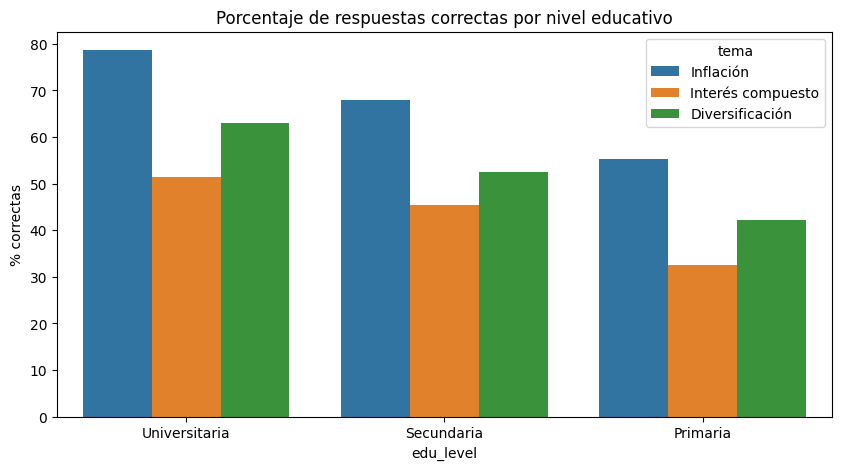

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(data=tabla_educ21, x='edu_level', y='%_correctas', hue='tema')
plt.title("Porcentaje de respuestas correctas por nivel educativo")
plt.ylabel("% correctas")
plt.show()


**La educación mejora el conocimiento financiero**

A mayor nivel educativo, mayor conocimiento financiero en los tres temas.

**Observación**
El nivel educativo aumenta el conocimiento financiero.
Las personas con educación universitaria muestran un dominio significativamente mayor en inflación, interés compuesto y diversificación.
El interés compuesto es el concepto más problemático para todos los grupos.

In [24]:
tabla_banco_educ = pd.crosstab(
    df_bank['education'],
    df_bank['default'],
    normalize='index'
).reset_index()

tabla_banco_educ = tabla_banco_educ.rename(columns={'yes': 'default'})
tabla_banco_educ = tabla_banco_educ[['education', 'default']]

# Pivotar para tener una fila por nivel educativo


pivot_educ = tabla_educ21.pivot(
    index='edu_level',
    columns='tema',
    values='%_correctas'
).reset_index()


# Mapeo encuesta → banco

map_edu = {
    'Primaria': 'primary',
    'Secundaria': 'secondary',
    'Universitaria': 'tertiary'
}

pivot_educ['education'] = pivot_educ['edu_level'].map(map_edu)

# Unir conocimientos ↔ riesgo (default)

cruce_educ_riesgo = pivot_educ.merge(tabla_banco_educ[['education', 'default']],
    on='education',
    how='left'
)

# Preparar datos para gráfico

df_plot = cruce_educ_riesgo.melt(
    id_vars='edu_level',
    value_vars=['Inflación', 'Interés compuesto', 'Diversificación', 'default'],
    var_name='variable',
    value_name='valor'
)

df_plot

,edu_level,variable,valor
0,Primaria,Inflación,55.300000
1,Secundaria,Inflación,67.900000
2,Universitaria,Inflación,78.700000
3,Primaria,Interés compuesto,32.500000
4,Secundaria,Interés compuesto,45.400000
5,Universitaria,Interés compuesto,51.500000
6,Primaria,Diversificación,42.100000
7,Secundaria,Diversificación,52.500000
8,Universitaria,Diversificación,63.000000
9,Primaria,default,0.019333


C:\Users\damia\AppData\Local\Temp\ipykernel_26512\4068773772.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_default, x='edu_level', y='valor', palette='viridis')


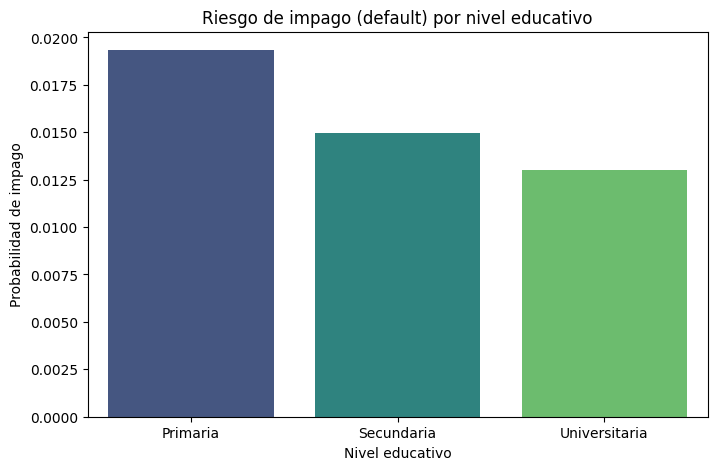

In [25]:
df_default = df_plot[df_plot['variable'] == 'default']

plt.figure(figsize=(8,5))
sns.barplot(data=df_default, x='edu_level', y='valor', palette='viridis')
plt.title("Riesgo de impago (default) por nivel educativo")
plt.ylabel("Probabilidad de impago")
plt.xlabel("Nivel educativo")
plt.show()


In [27]:
df_nat16['Año_entrev.'] = 2016
df_nat21['Año_entrev.'] = 2021

df_nat = pd.concat([df_nat16, df_nat21], ignore_index=True)

In [29]:
df_nat['Ahorro'] = (
    (df_nat['AhorroEfectivo'] == 1) |
    (df_nat['AhorroCuentaCorriente'] == 1) |
    (df_nat['AhorroPlazoFijo'] == 1)
).astype(int)

df_nat['score_competencia'] = (
    df_nat['Ahorro'].fillna(0) +
    df_nat['UsoAhorros'].fillna(0) +
    df_nat['PlanificacionHogar'].fillna(0) -
    df_nat['SinAhorro'].fillna(0) -
    df_nat['Impagos'].fillna(0) -
    df_nat['GastosMayoresIngresos'].fillna(0))

df_nat['nivel_competencia'] = pd.cut(
    df_nat['score_competencia'],
    bins=3,
    labels=['Baja','Media','Alta']
)

In [30]:
df_bank['score_competencia'] = (
    (df_bank['balance'] > 0).astype(int) +      
    (df_bank['deposit'] == 'yes').astype(int) - 
    (df_bank['default'] == 'yes').astype(int)   
)

df_bank['nivel_competencia'] = pd.cut(
    df_bank['score_competencia'],
    bins=[-5, -1, 1, 3],
    labels=['Baja', 'Media', 'Alta']
)

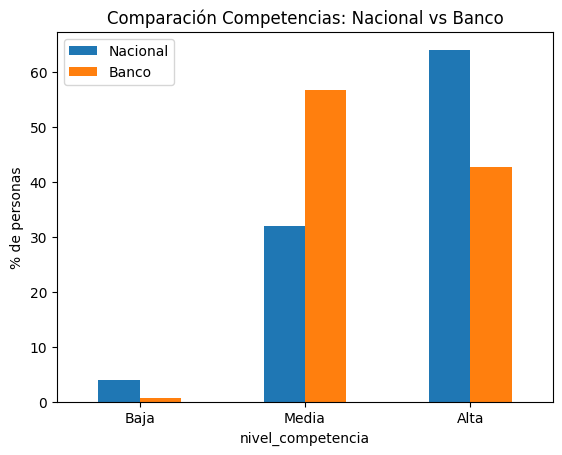

In [32]:
# Nacional
dist_nat = df_nat['nivel_competencia'].value_counts(normalize=True)

# Banco
dist_bank = df_bank['nivel_competencia'].value_counts(normalize=True)

comparacion = pd.concat([dist_nat, dist_bank], axis=1)
comparacion.columns = ['Nacional', 'Banco']

orden = ['Baja', 'Media', 'Alta']
comparacion = comparacion.reindex(orden)
comparacion_pct = comparacion * 100

comparacion_pct.plot(kind='bar')

plt.title('Comparación Competencias: Nacional vs Banco')
plt.ylabel('% de personas')
plt.xticks(rotation=0)

plt.show()


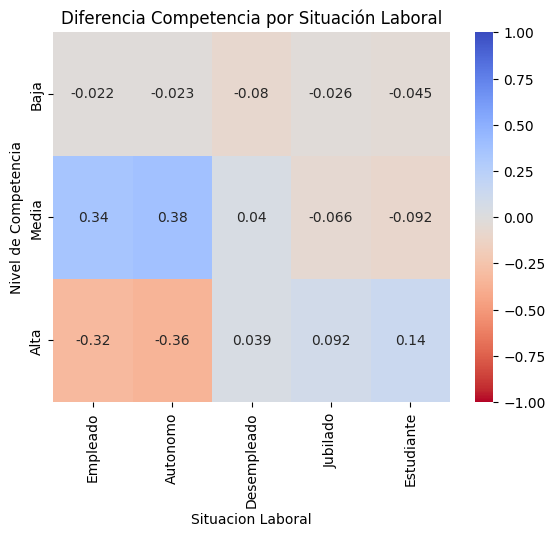

In [33]:
# Nacional
df_nat['laboral_simplificada'] = (
    df_nat['labor_status']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'autónomo': 'Autonomo',
        'autã³nomo': 'Autonomo',
        'desempleado': 'Desempleado',
        'jubilado': 'Jubilado',
        'otros inactivos': 'Estudiante', 
        'missing': 'Empleado'
    })
)

tabla_nat = pd.crosstab(
    df_nat['nivel_competencia'],
    df_nat['laboral_simplificada'],
    normalize='columns'
)


# Banco
df_bank['laboral_simplificada'] = df_bank['job'].map({
    'unemployed': 'Desempleado',
    'retired': 'Jubilado',
    'student': 'Estudiante',
    'self-employed': 'Autonomo',
    'entrepreneur': 'Autonomo'
})

df_bank['laboral_simplificada'] = df_bank['laboral_simplificada'].fillna('Empleado')

tabla_bank = pd.crosstab(
    df_bank['nivel_competencia'],
    df_bank['laboral_simplificada'],
    normalize='columns'
)

orden = ['Empleado', 'Autonomo', 'Desempleado', 'Jubilado', 'Estudiante']

tabla_nat = tabla_nat.reindex(columns=orden)
tabla_bank = tabla_bank.reindex(columns=orden)

tabla_diff = tabla_bank - tabla_nat

sns.heatmap(
    tabla_diff,
    annot=True,
    cmap='coolwarm_r',   
    vmin=-1,
    vmax=1
)

plt.title('Diferencia Competencia por Situación Laboral')
plt.ylabel('Nivel de Competencia')
plt.xlabel('Situacion Laboral')
plt.show()

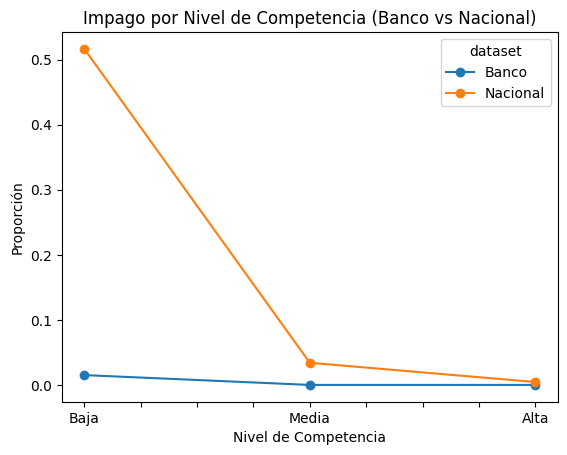

In [34]:
#Copias
df_bank_c = df_bank.copy()
df_nat_c = df_nat.copy()

#Banco → crear variables
df_bank_c['CreditoFormal'] = (
    (df_bank_c['housing'] == 'yes') | 
    (df_bank_c['loan'] == 'yes')
).astype(int)

df_bank_c['Impagos'] = (df_bank_c['default'] == 'yes').astype(int)

df_bank_c['nivel_competencia'] = pd.cut(
    df_bank_c['balance'],
    bins=3,
    labels=['Baja','Media','Alta']
)

df_bank_c['dataset'] = 'Banco'

#Nacional
df_nat_c['dataset'] = 'Nacional'
df_nat_c['Impagos'] = df_nat_c['Impagos'].astype(int)

df_nat_c['nivel_competencia'] = pd.cut(
    df_nat_c['score_competencia'],
    bins=3,
    labels=['Baja','Media','Alta']
)

#CONCAT FINAL
df_total = pd.concat([
    df_nat_c[['nivel_competencia','CreditoFormal','Impagos','dataset']],
    df_bank_c[['nivel_competencia','CreditoFormal','Impagos','dataset']]
])


tabla = pd.crosstab(
    [df_total['dataset'], df_total['nivel_competencia']],
    df_total['Impagos'],
    normalize='index'
)

#copia
tabla_c = tabla.reset_index().copy()

tabla_c = tabla_c.rename(columns={1: 'prop_impago'})

tabla_pivot = tabla_c.pivot(
    index='nivel_competencia',
    columns='dataset',
    values='prop_impago'
)

tabla_pivot.plot(marker='o')
plt.title('Impago por Nivel de Competencia (Banco vs Nacional)')
plt.ylabel('Proporción')
plt.xlabel('Nivel de Competencia')
plt.show()